# Visualization Showcase
2025-11-23

This notebook showcases some of the functionality of visualizing velocity fields, using the CloudAtlasVisualizationExt.

In order to use the visualization tools of CloudAtlas, you need to be `using CairoMakie`. 
CairoMakie is kept as a weak dependency to maintain the independence of the main CloudAtlas software.

By default, the laminar baseflow is disabled. You might be surprised by the streamwise velocity because of that.
All plotting functions have an optional `add_baseflow` flag which enables the laminar flow by just adding the $y$ coordinate to $u$.

In [1]:
using Revise, DelimitedFiles, BenchmarkTools, LinearAlgebra, Polynomials
using CairoMakie # this triggers the extension to load
using CloudAtlas

"""
    myreaddlm(filename, cc='%')

Read matrix or vector from a file, dropping comments marked with cc.
"""
function myreaddlm(filename; cc='%')
    X = readdlm(filename, comments=true, comment_char=cc)
    if size(X,2) == 1
        X = X[:,1]
    end
    X
end

sx, sy, sz, tx, tz = halfbox_symmetries()

pwd()

[ Info: Precompiling CloudAtlasVisualizationExt [91dd8eae-e5c9-5f98-bbaa-dfe67aeb58cb] (cache misses: include_dependency fsize change (2))


"/home/ebenq/Dev/julia/CloudAtlas.jl/notebooks"

## Visualizing a Field
The following showcases the visualization of a field equilibrium. First, we find the eqb.

## Comparison to DNS Data
An important comparison is visualizing how the velocity field relates to the DNS data. The following demonstrates such a comparison.

This uses a fairly high resolution model, with a 320 variable ODE model. 

The DNS data is generated with the `plotfield` Channelflow utility, which is included in the `chflow-programs` directory.

In [10]:
α, γ = 1.0, 2.0                     # Fourier wavenumbers α, γ = 2π/Lx, 2π/Lz
J,K,L = 3,3,6                       # Bounds on Fourier modes (J,K) and wall-normal polynomials (L)
H = [(sx*sy)*(tx*tz)]               # Generators of the symmetric subspace of TW1
normalize = false                   # Normalize the basis set or not?
model_336 = ODEModel(α, γ, J, K, L, H, normalize=normalize);  # Construct ODE model by Galerkin projection 

J,K,L,m == 3,3,6,320
(2J+1)(2K+1)(2L+1) + 1 == 638
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249 

In [41]:
α, γ = 1.0, 2.0                     # Fourier wavenumbers α, γ = 2π/Lx, 2π/Lz
J,K,L = 1,2,3# Bounds on Fourier modes (J,K) and wall-normal polynomials (L)
H = [(sx*sy)*(tx*tz)]               # Generators of the symmetric subspace of TW1
normalize = false                   # Normalize the basis set or not?
model = ODEModel(α, γ, J, K, L, H, normalize=normalize)  # Construct ODE model by Galerkin projection 
@show m = length(model)             # dimension of ODE model

J,K,L,m == 1,2,3,53
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 
m = length(model) = 53


53

In [42]:
# Parameters
hookparams = SearchParams(ftol=1e-08, xtol=1e-12, Nnewton=30,Nhook=8,δ=0.01, verbosity=0)
R = 200
x0_raw = myreaddlm("data/xtw1projection-Re200-3-3-6-320d.asc")
x0 = changebasis(x0_raw, model_336.ijkl, model.ijkl) 
# x_guess = randn(m)
# x0 = 0.40/norm(x_guess) * x_guess
# x0 = randn(m)

# Create closures for g and Dg that capture R
f_closure(x) = model.f(x, R)
Df_closure(x) = model.Df(x, R)

# Use hookstep to find a solution
ξ_final, converged = hookstepsolve(f_closure, Df_closure, x0, hookparams)
x_sol = ξ_final[1:m]
println("Norm of solution: ", norm(x_sol))
println("Converged: ", converged)

Norm of solution: 0.41787947132057013
Converged: true


DNS grid: Nx × Ny × Nz = 41 × 49 × 41


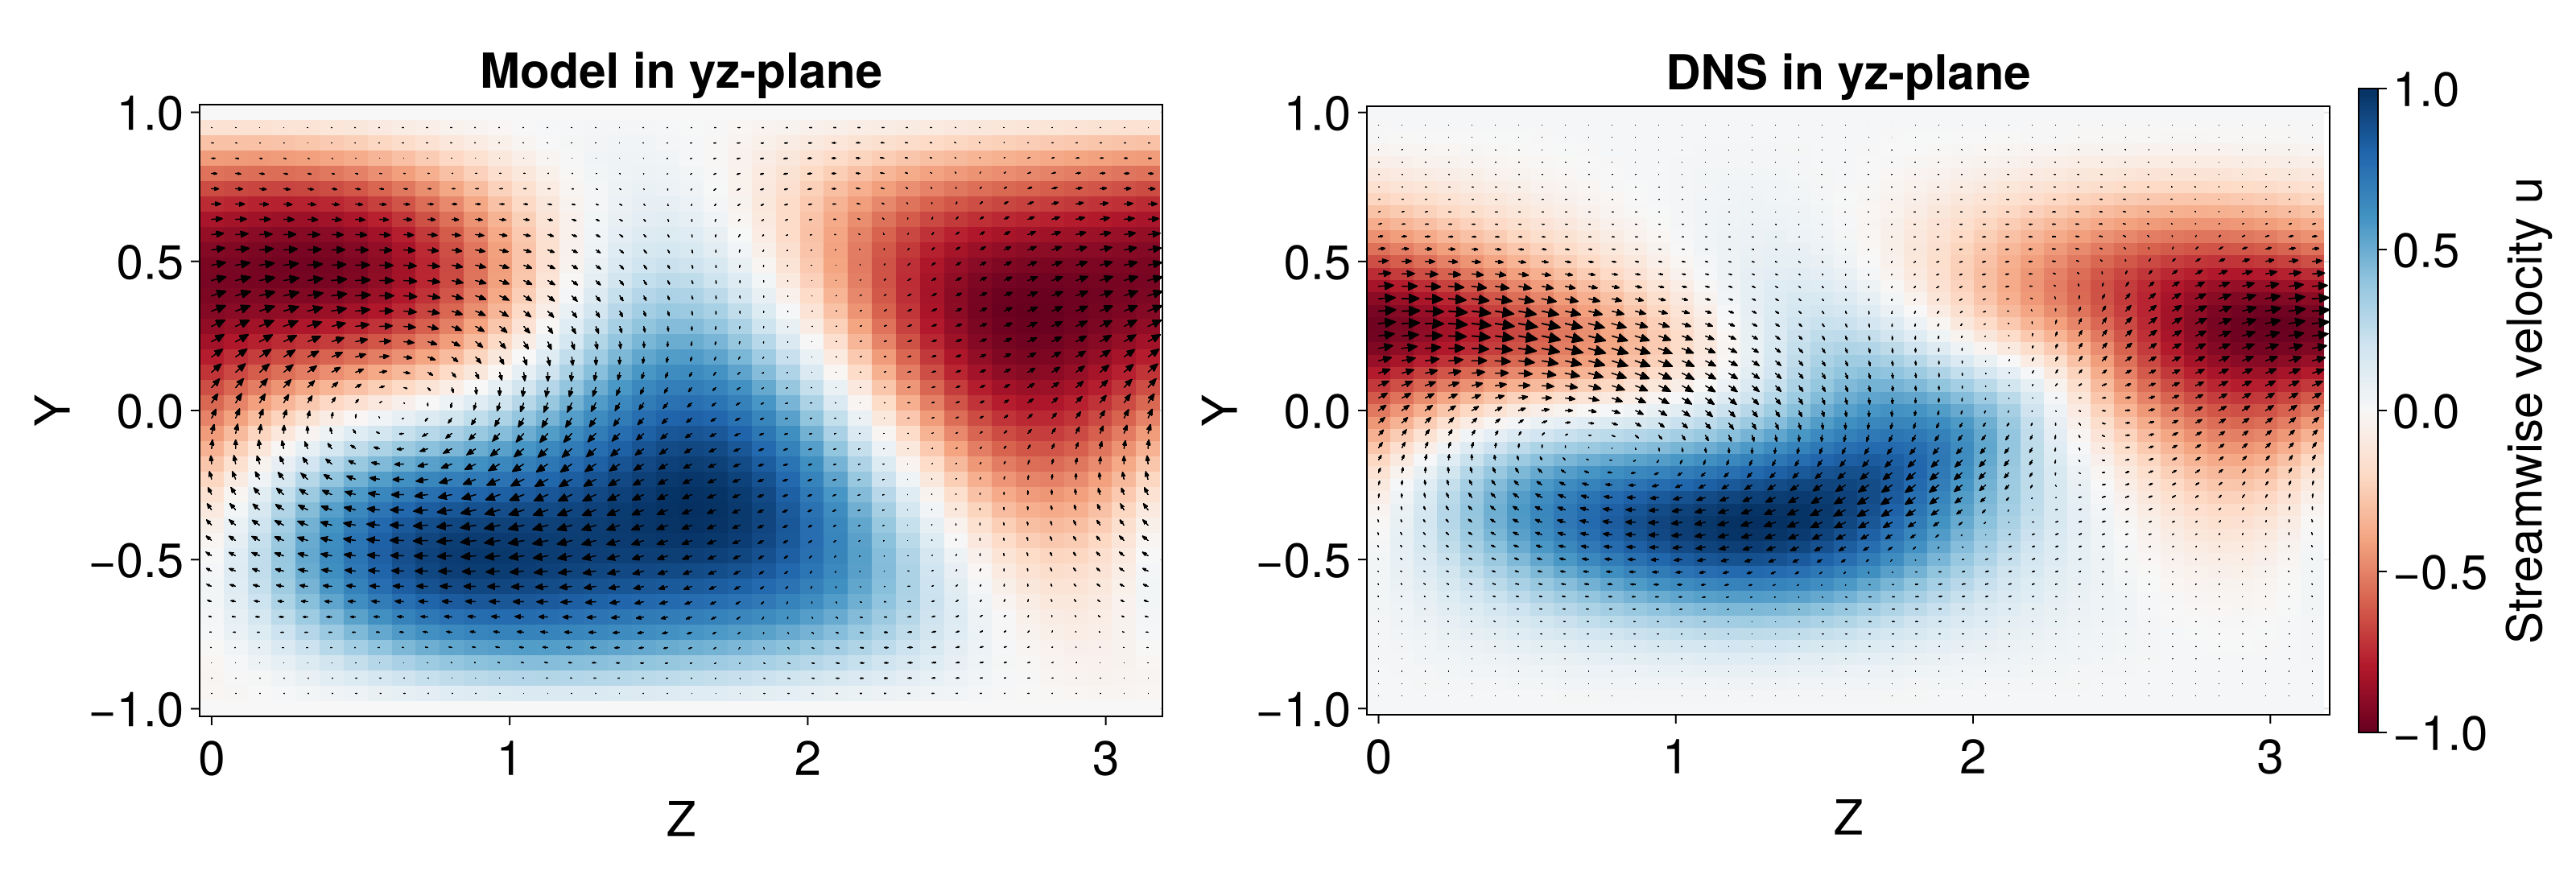

In [45]:
# settings = PlotSettings(num_points = 40)
cmap = [:navyblue, :aqua, :lime, :orange, :red4]
cmap = (:RdBu, 1.0)
settings = PlotSettings(num_points=40, colormap=cmap, arrow_scale=0.5)
fig1, fig2, fig3 = velocity_fields_comparison(model, x_sol, "./data/tw1_plots/TW1-2pi1piRe200-40x49x40"; settings=settings, add_baseflow = false)
display(fig3)
CairoMakie.save("yz-plane-comparison.png", fig3)


In [8]:
# display(fig1)

In [86]:
# display(fig2)

## Adding Baseflow
The following graphs demonstrate what changes when we enable the `add_baseflow` flag. Notably, you need DNS data that also has the laminar profile added, which could be done with the `addfield` Channelflow utility. 

In [11]:
fig1, fig2, fig3 = velocity_fields_comparison(model, x_sol, "./data/tw1_plots/TW1_Re200_with_baseflow"; settings=settings, add_baseflow = true)

DNS grid: Nx × Ny × Nz = 41 × 49 × 41


(Scene(2 children, 0 plots), Scene(2 children, 0 plots), Scene(3 children, 0 plots))

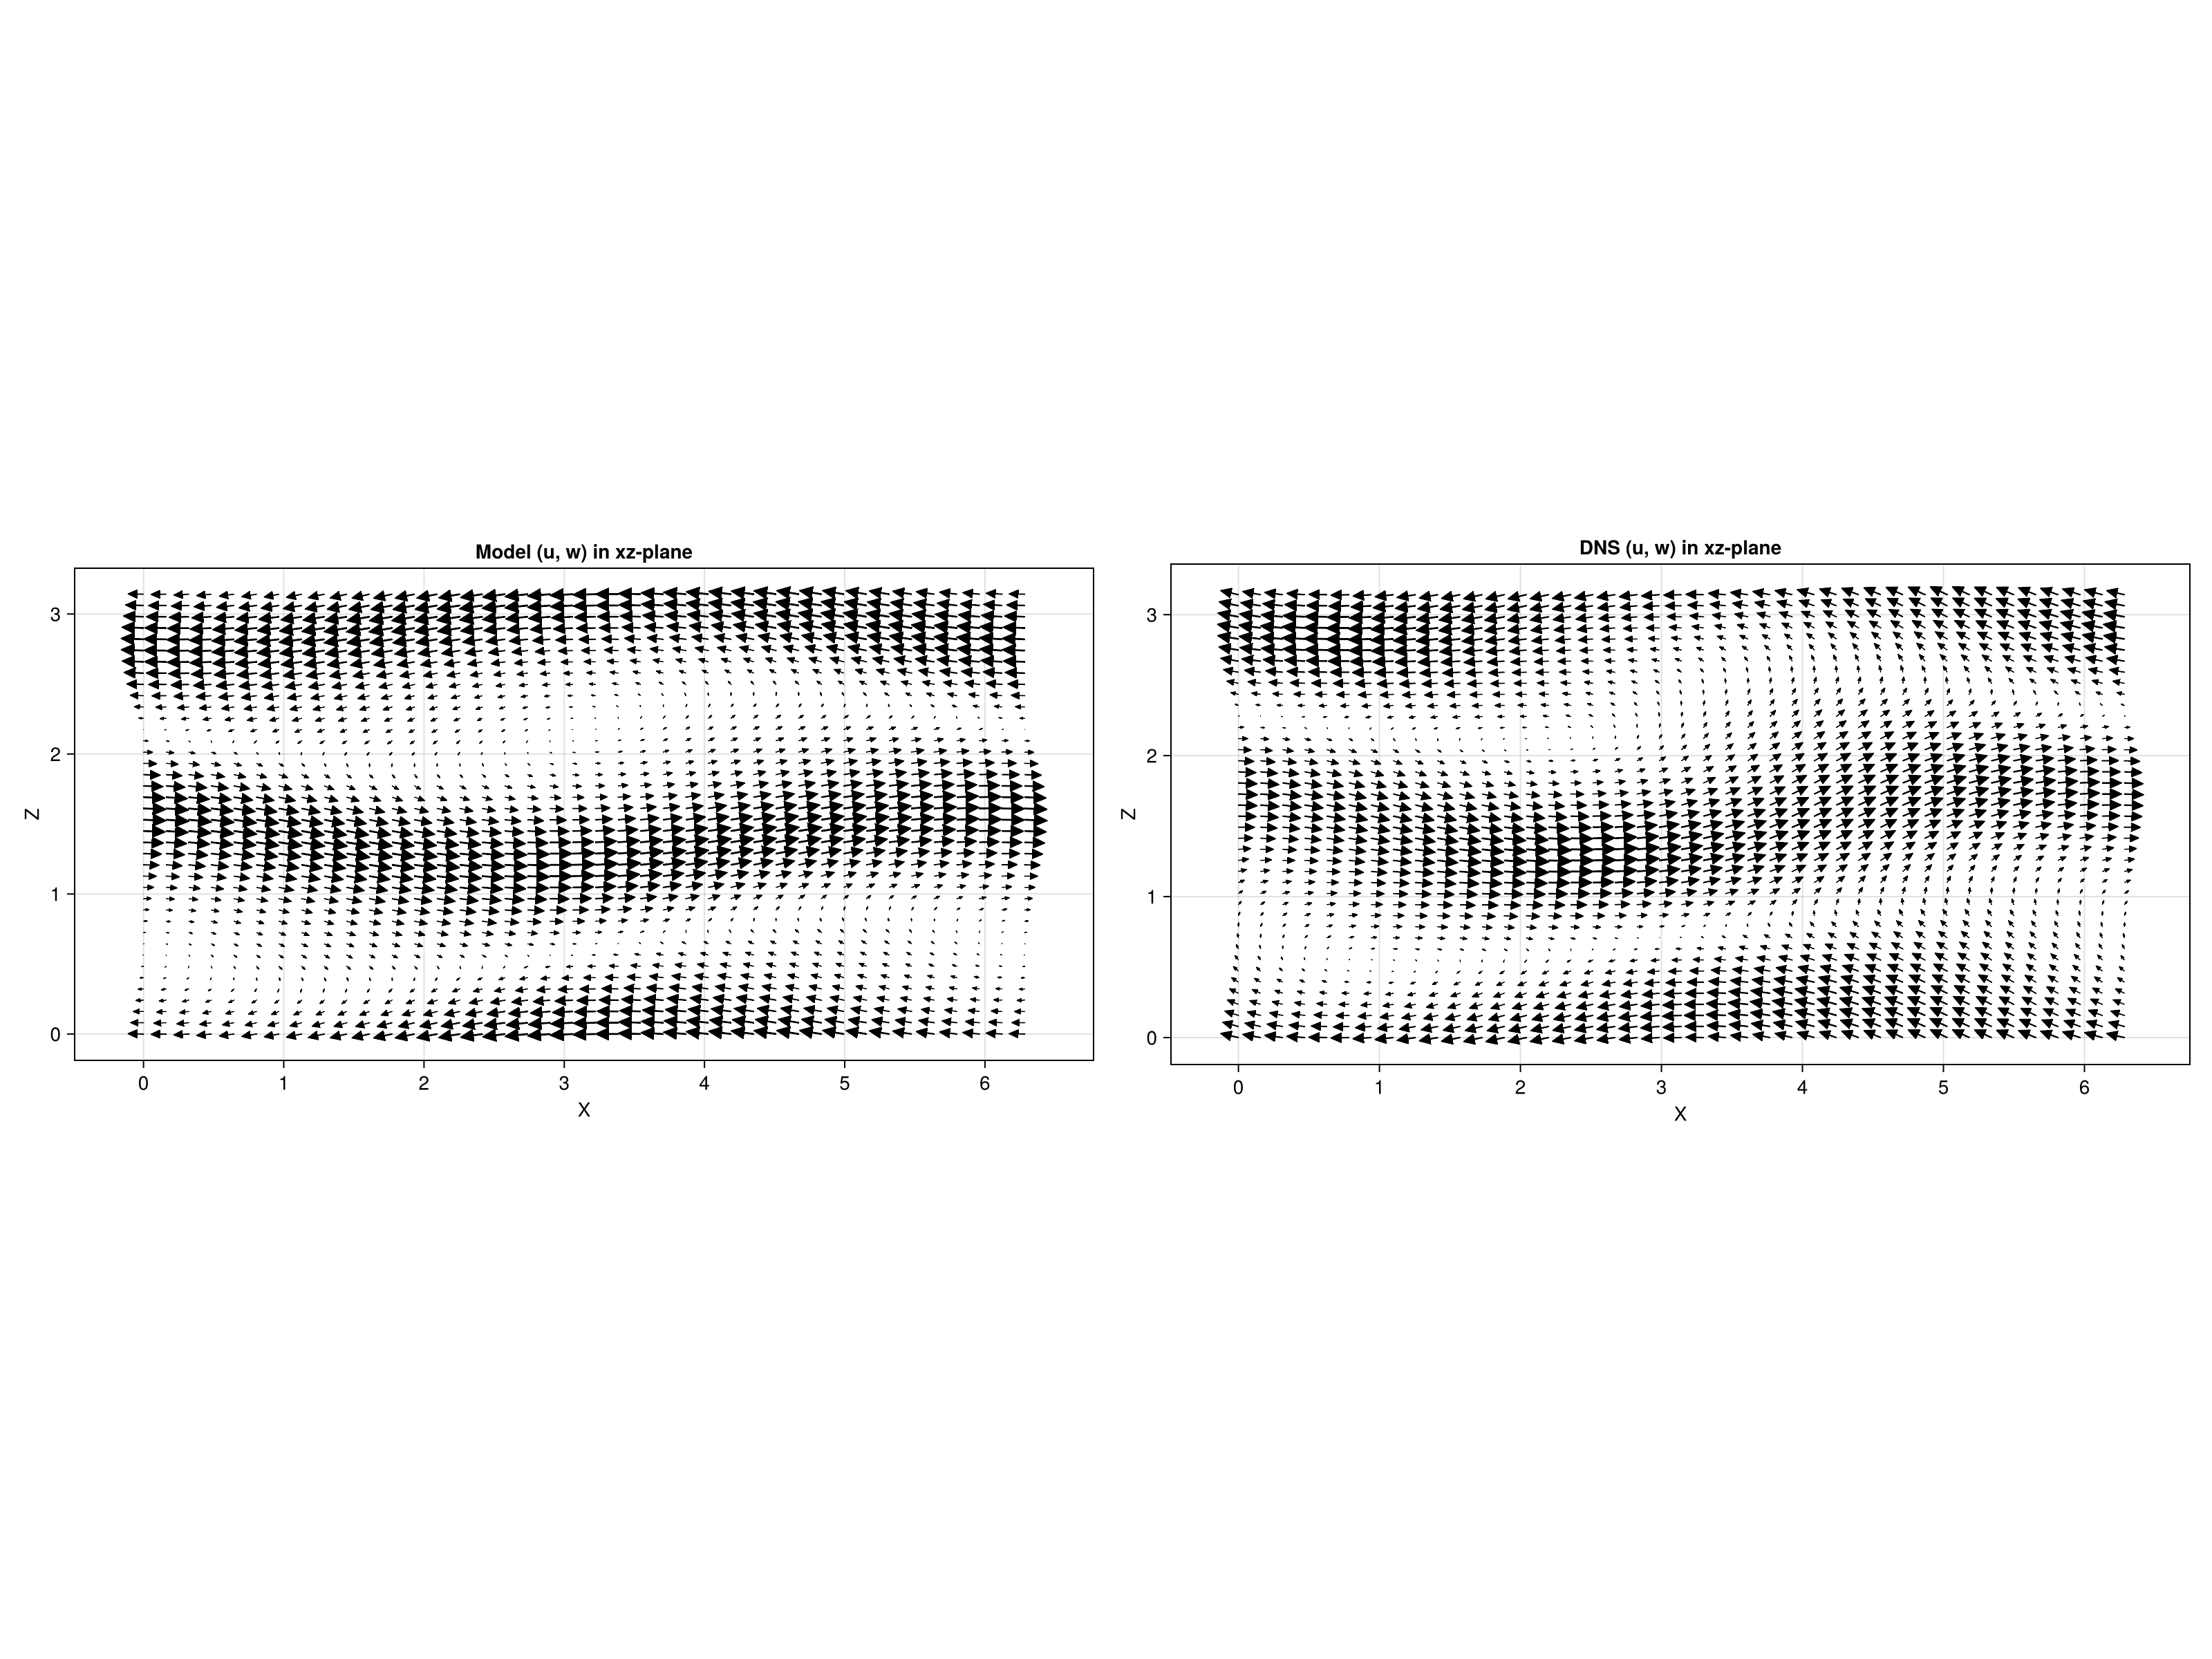

CairoMakie.Screen{IMAGE}


In [12]:
display(fig1)

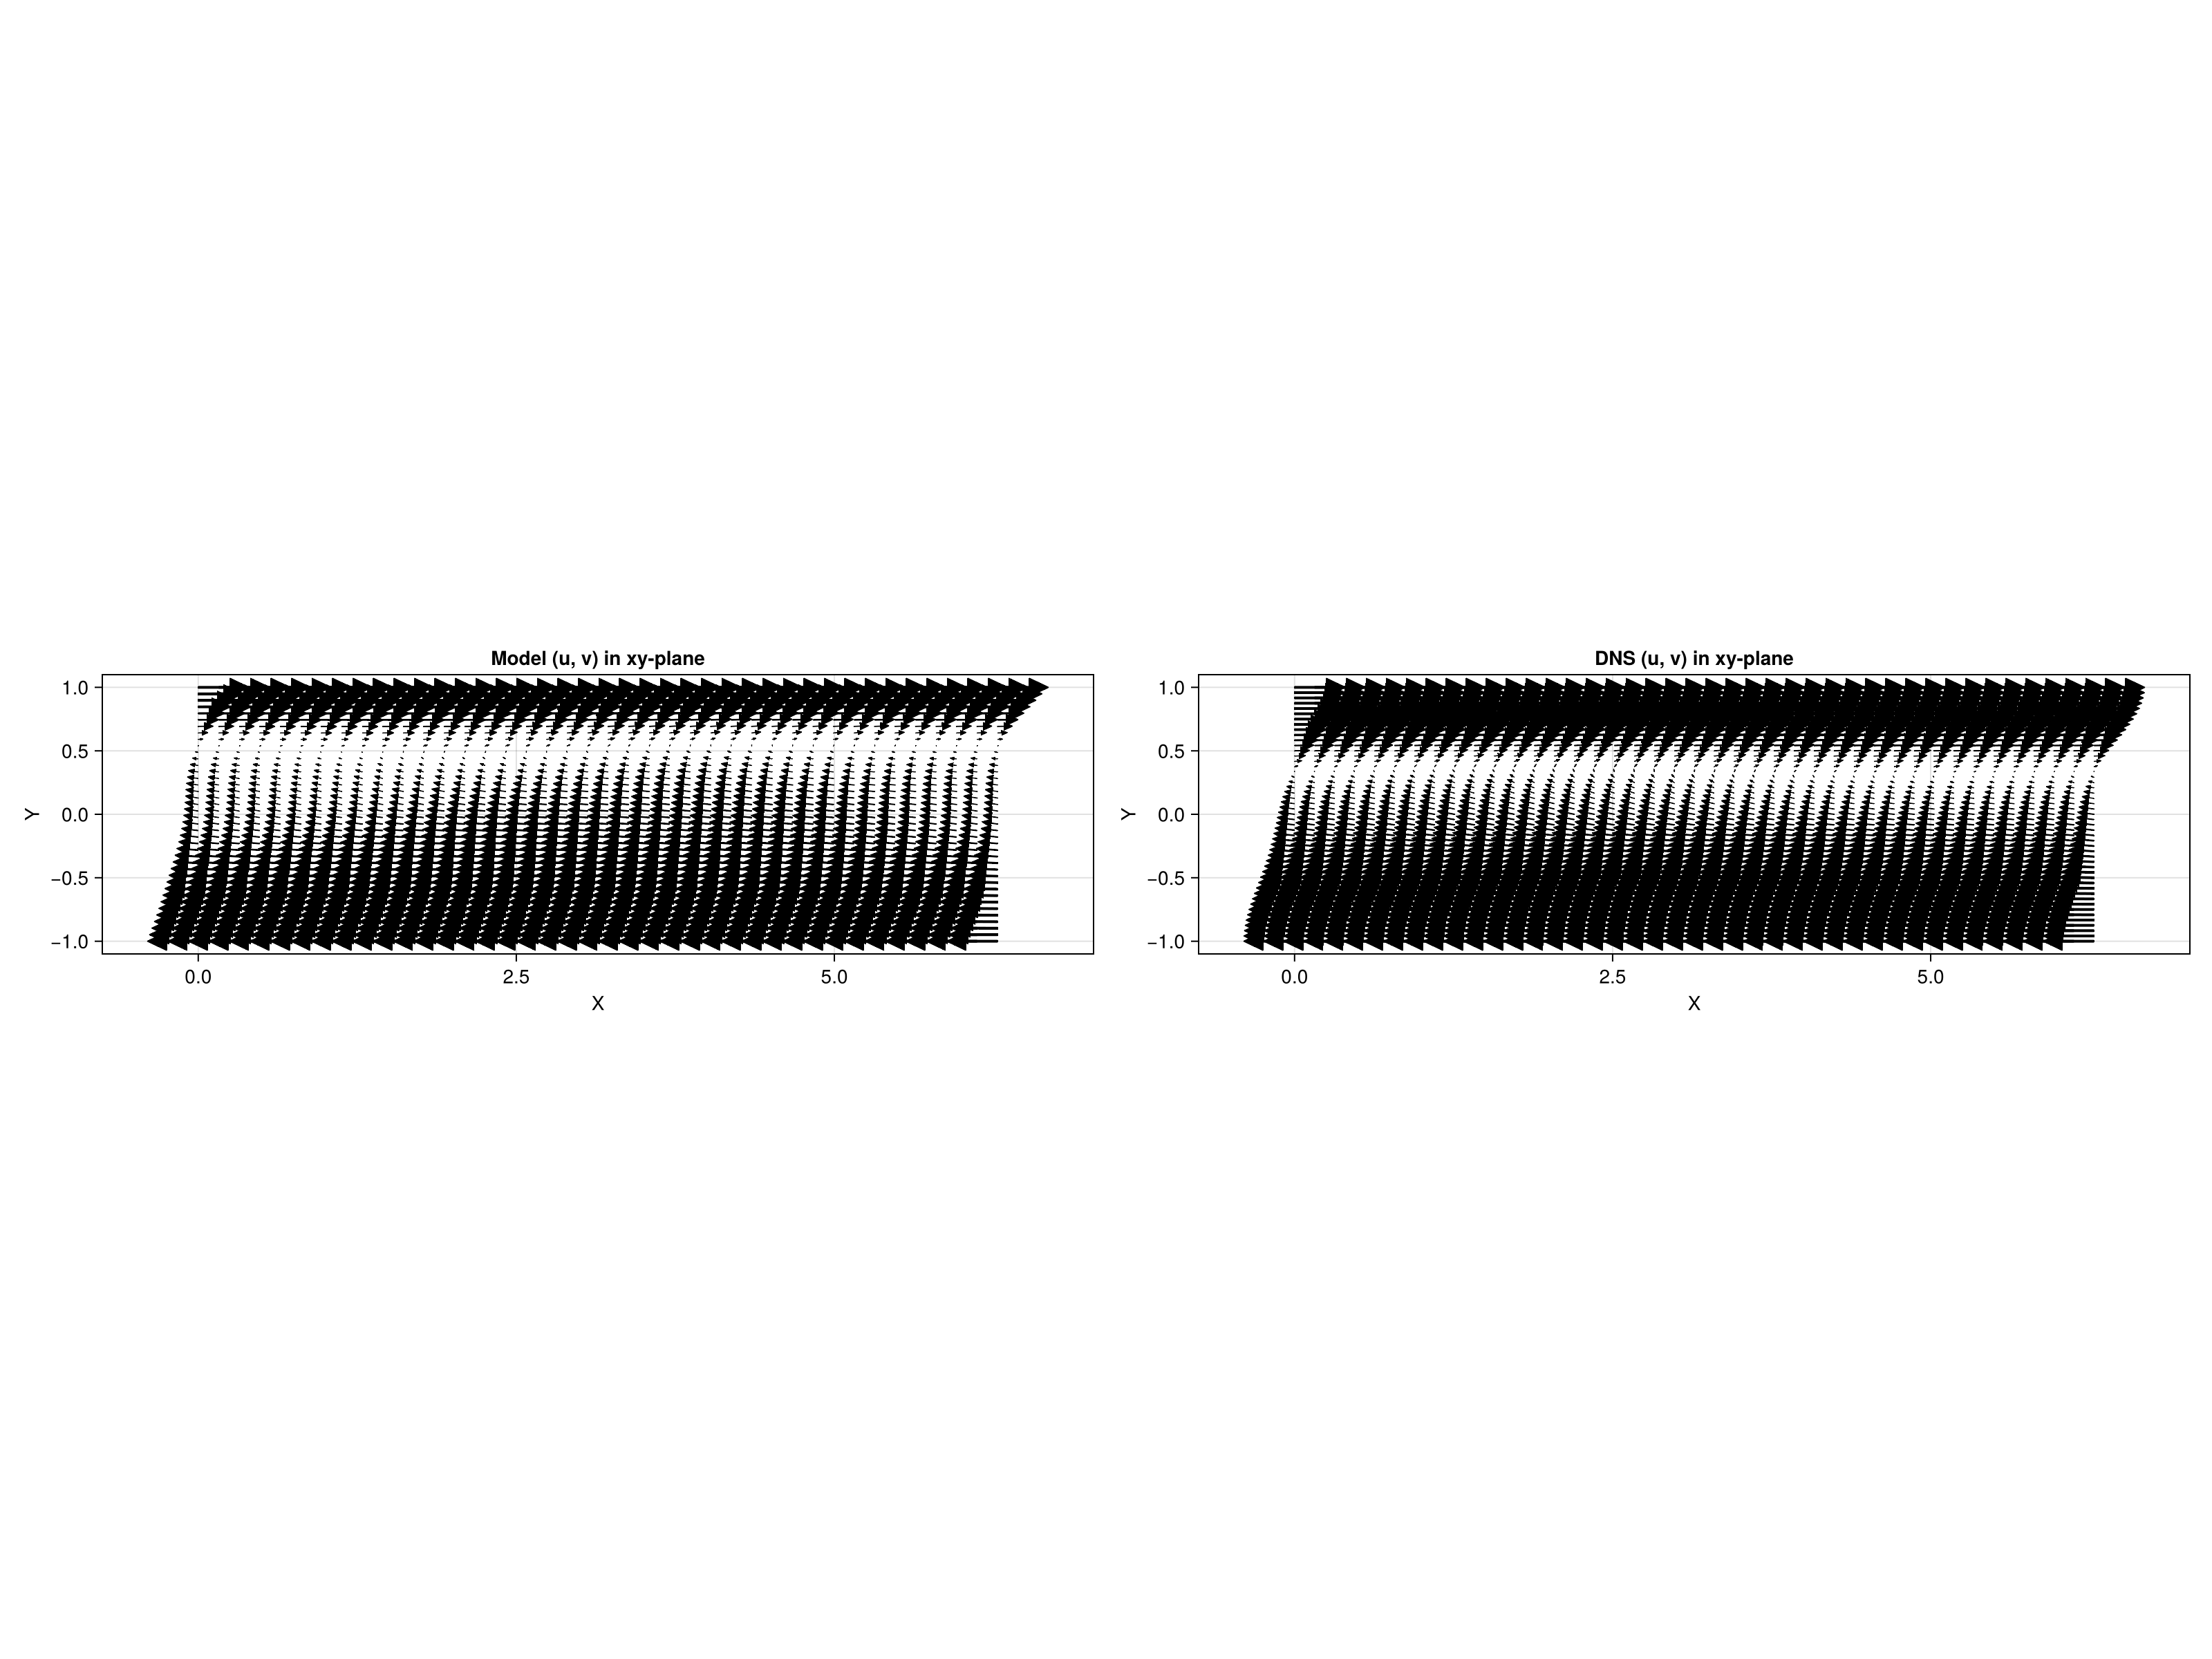

CairoMakie.Screen{IMAGE}


In [13]:
display(fig2)

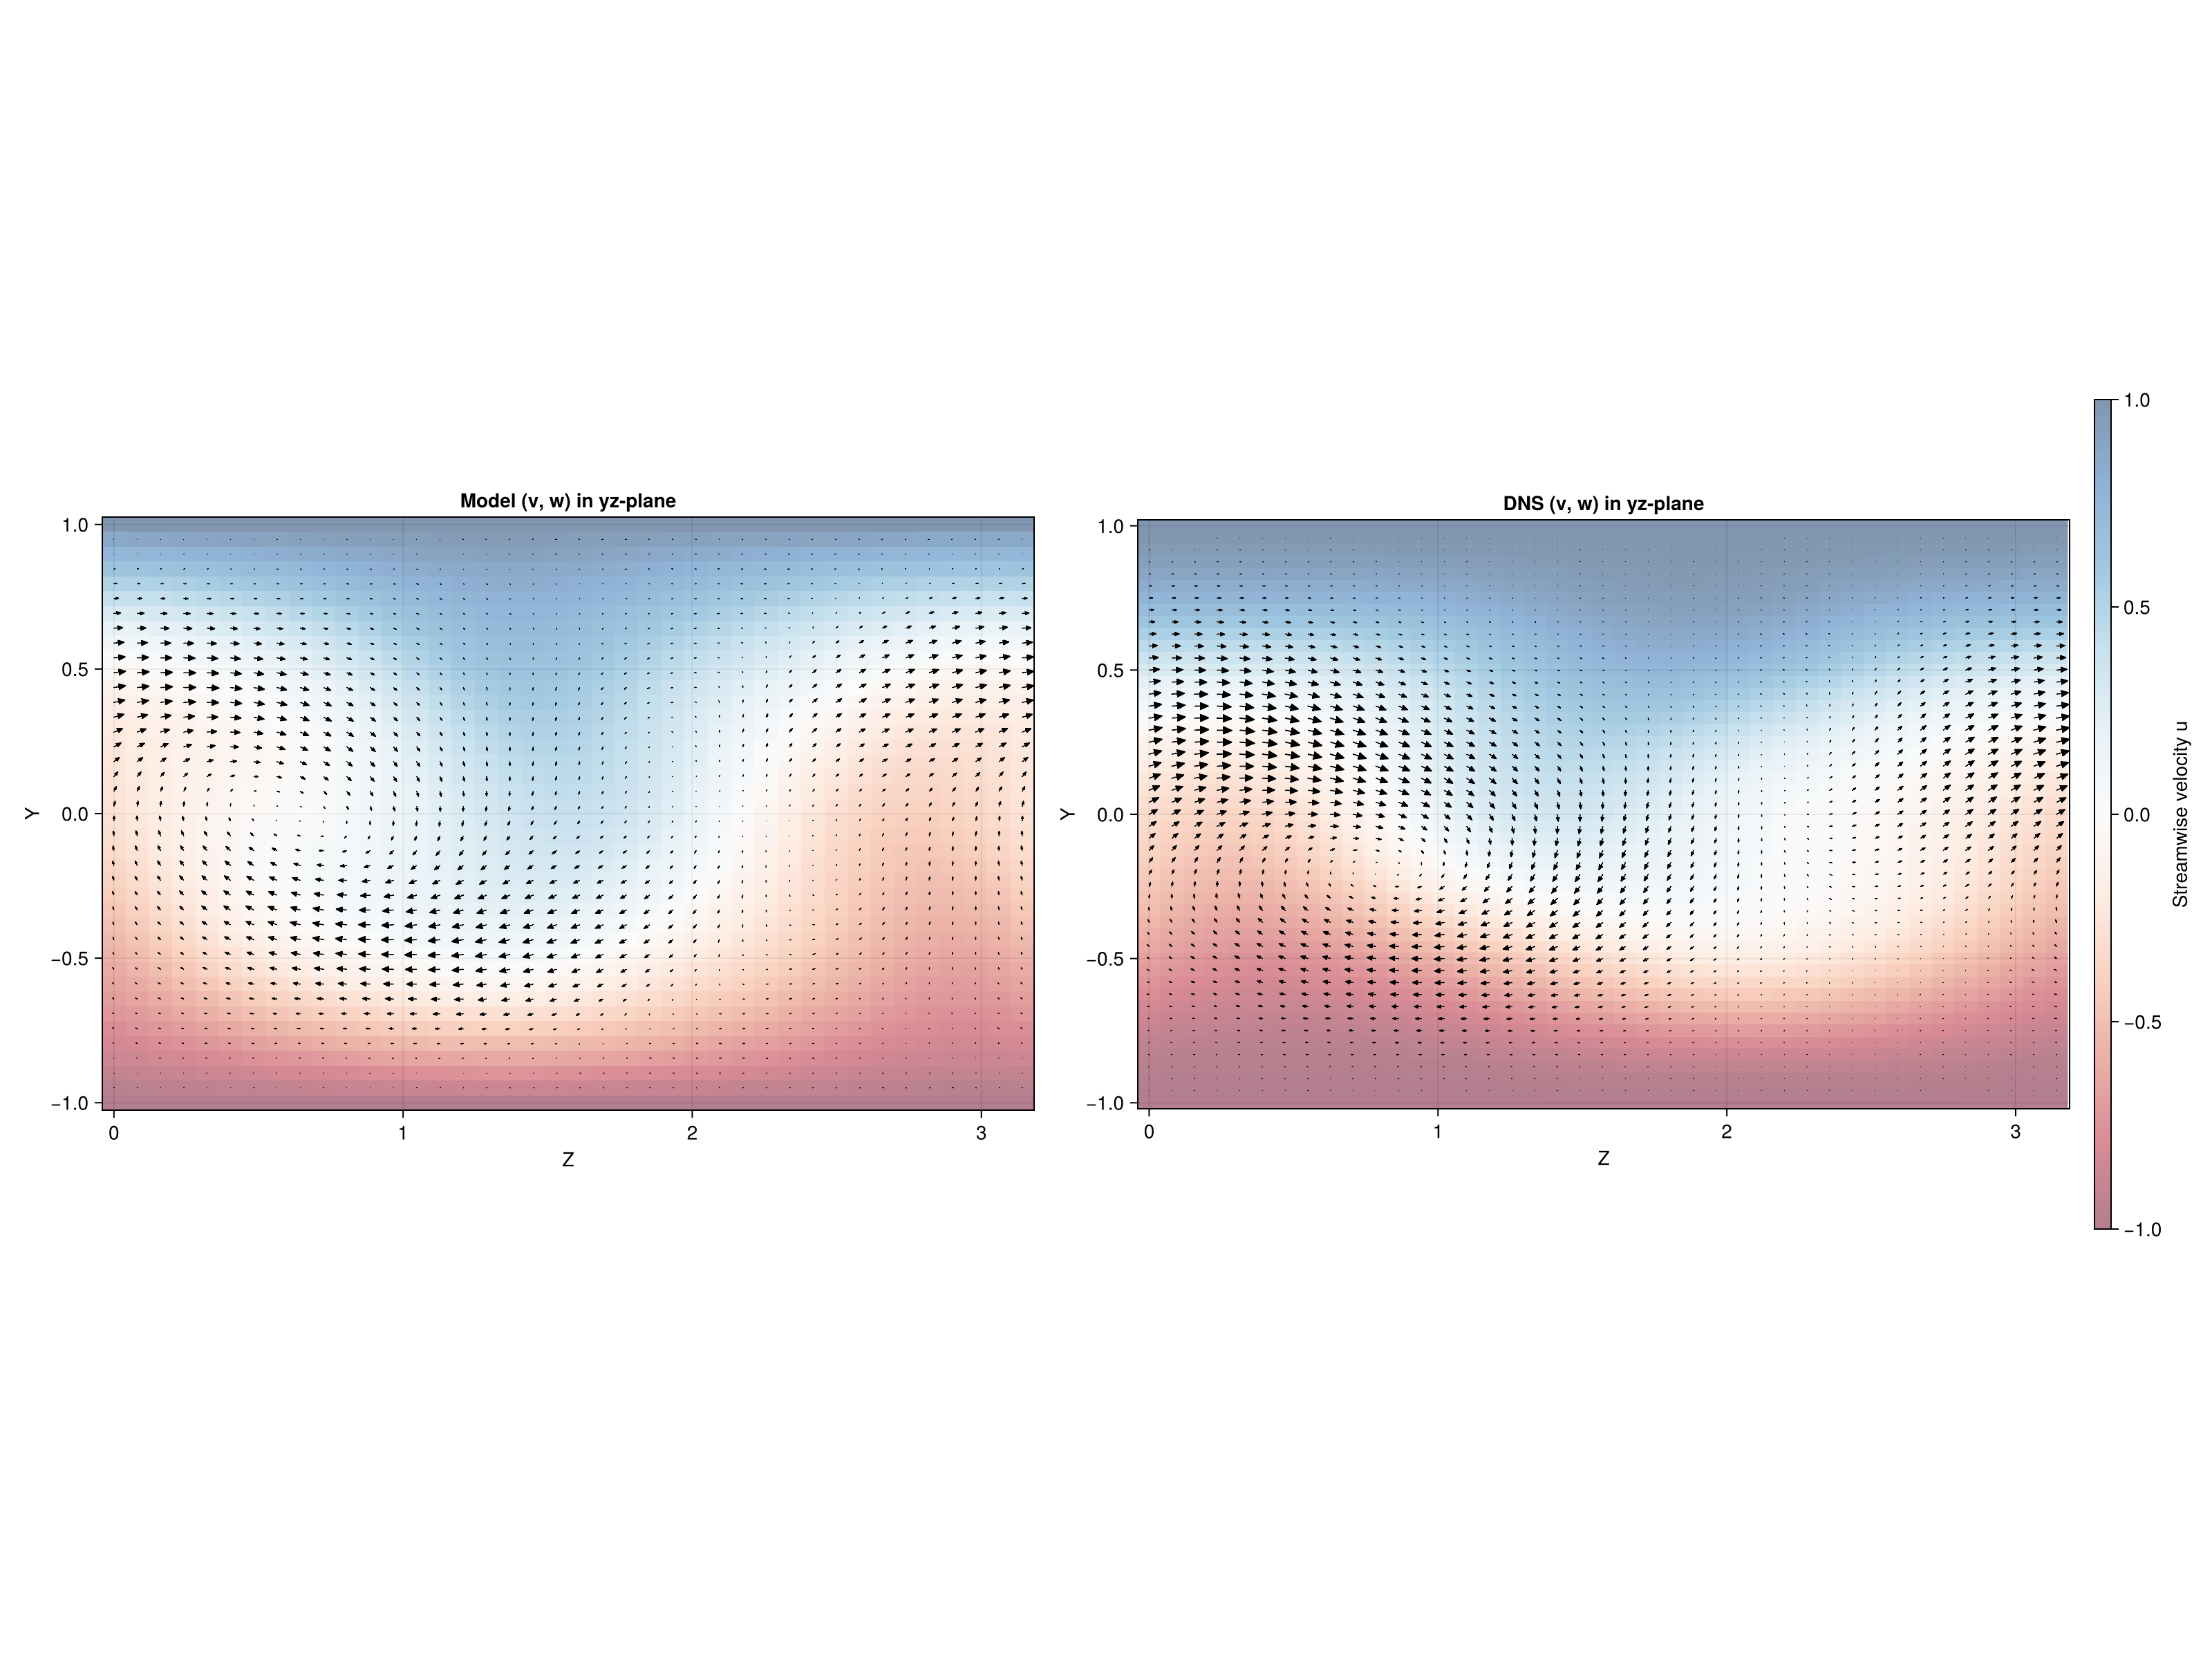

CairoMakie.Screen{IMAGE}


In [14]:
display(fig3)

In [15]:
# ===== Arrow Drawing Utilities =====
using Plots
using CloudAtlas
using DelimitedFiles

plot = Plots.plot
plot! = Plots.plot!

"""
    invhypot(x, y)

Return 1/√(x² + y²) for (x,y) ≠ (0,0), or 0.0 for (x,y) == (0,0).
Useful for normalized quiver plots.
"""
invhypot(x, y) = (abs(x) + abs(y) > 0) ? 1/hypot(x, y) : 0.0

"""
    arrow0!(x, y, u, v; as=0.07, lc=:black, la=1)

Draw a single arrow from (x,y) to (x+u, y+v) with arrowhead.

# Arguments
- `x, y`: Starting position
- `u, v`: Arrow components
- `as`: Arrow head size (0-1, fraction of arrow length)
- `lc`: Line color
- `la`: Line alpha (transparency)
"""
function arrow0!(x, y, u, v; as=0.07, lc=:black, la=1)
    nuv = sqrt(u^2 + v^2)
    v1, v2 = [u; v] / nuv, [-v; u] / nuv
    v4 = (3*v1 + v2) / 3.1623  # sqrt(10) to get unit vector
    v5 = v4 - 2*(v4'*v2)*v2
    v4, v5 = as*nuv*v4, as*nuv*v5
    plot!([x, x+u], [y, y+v], lc=lc, la=la, label="")
    plot!([x+u, x+u-v5[1]], [y+v, y+v-v5[2]], lc=lc, la=la, label="")
    plot!([x+u, x+u-v4[1]], [y+v, y+v-v4[2]], lc=lc, la=la, label="")
end

"""
    newquiver!(x, y, u, v; lc=:black, scale=1, arrowsize=0.1)

Add quiver plot to current plot.

# Arguments
- `x`: Vector of x coordinates
- `y`: Vector of y coordinates  
- `u`: Matrix u[iy, ix] of x-components at (x[ix], y[iy])
- `v`: Matrix v[iy, ix] of y-components at (x[ix], y[iy])
- `lc`: Line color
- `scale`: Scale factor for arrow length
- `arrowsize`: Size of arrowhead (0-1)

Note: Matrix convention is u[iy, ix] to match standard plotting convention
where first index is row (y) and second is column (x).
"""
function newquiver!(x, y, u, v; lc=:black, scale=1, arrowsize=0.1)
    u_scaled = u * scale
    v_scaled = v * scale
    nx = length(x)
    ny = length(y)
    
    # Verify dimensions
    if size(u) != (ny, nx) || size(v) != (ny, nx)
        error("Matrix dimensions don't match: u is $(size(u)), v is $(size(v)), but expected ($ny, $nx)")
    end
    
    for ix in 1:nx
        for iy in 1:ny
            arrow0!(x[ix], y[iy], u_scaled[iy, ix], v_scaled[iy, ix], 
                   lc=lc, as=arrowsize)
        end
    end
    plot!()
end

"""
    newquiver(x, y, u, v; lc=:black, scale=1, arrowsize=0.1)

Create new quiver plot.
"""
function newquiver(x, y, u, v; lc=:black, scale=1, arrowsize=0.1)
    plot()
    newquiver!(x, y, u, v; lc=lc, scale=scale, arrowsize=arrowsize)
end

# ===== Velocity Field Extraction =====

"""
    extract_xz_plane(model, x, y_val=0.0; Lx=2π, Lz=π, nx=40, nz=20, add_baseflow=false)

Extract (u, w) velocity components in xz-plane at fixed y.
Returns (x_grid, z_grid, u_matrix, w_matrix) ready for quiver plotting.

Note: Matrices are returned with shape (nz, nx) to match plotting convention.
"""
function extract_xz_plane(model::Union{CloudAtlas.ODEModel, CloudAtlas.TWModel}, 
                          x::Vector, y_val=0.0;
                          Lx=2π, Lz=π, nx=40, nz=20, 
                          add_baseflow=false)
    
    vf = VelocityField(model, x; add_baseflow=add_baseflow)
    
    x_grid = range(0, Lx, length=nx)
    z_grid = range(0, Lz, length=nz)
    
    # Build matrices: u[iz, ix] corresponds to (x[ix], z[iz])
    # First index is z (rows), second index is x (columns)
    u_matrix = [vf(:u, x_grid[ix], y_val, z_grid[iz]) for iz in 1:nz, ix in 1:nx]
    w_matrix = [vf(:w, x_grid[ix], y_val, z_grid[iz]) for iz in 1:nz, ix in 1:nx]
    
    return (x_grid, z_grid, u_matrix, w_matrix)
end

"""
    extract_xy_plane(model, x, z_val=0.0; Lx=2π, nx=40, ny=20, add_baseflow=false)

Extract (u, v) velocity components in xy-plane at fixed z.
Returns matrices with shape (ny, nx).
"""
function extract_xy_plane(model::Union{CloudAtlas.ODEModel, CloudAtlas.TWModel}, 
                          x::Vector, z_val=0.0;
                          Lx=2π, nx=40, ny=20,
                          add_baseflow=false)
    
    vf = VelocityField(model, x; add_baseflow=add_baseflow)
    
    x_grid = range(0, Lx, length=nx)
    y_grid = range(-1, 1, length=ny)
    
    # u[iy, ix] for (x[ix], y[iy])
    u_matrix = [vf(:u, x_grid[ix], y_grid[iy], z_val) for iy in 1:ny, ix in 1:nx]
    v_matrix = [vf(:v, x_grid[ix], y_grid[iy], z_val) for iy in 1:ny, ix in 1:nx]
    
    return (x_grid, y_grid, u_matrix, v_matrix)
end

"""
    extract_yz_plane(model, x, x_val=0.0; Lz=π, ny=20, nz=20, add_baseflow=false)

Extract (v, w) velocity components in yz-plane at fixed x.
"""
function extract_yz_plane(model::Union{CloudAtlas.ODEModel, CloudAtlas.TWModel}, 
                          x::Vector, x_val=0.0;
                          Lz=π, ny=20, nz=20,
                          add_baseflow=false)
    
    vf = VelocityField(model, x; add_baseflow=add_baseflow)
    
    y_grid = range(-1, 1, length=ny)
    z_grid = range(0, Lz, length=nz)
    
    v_matrix = [vf(:v, x_val, y_grid[iy], z_grid[iz]) for iz in 1:nz, iy in 1:ny]
    w_matrix = [vf(:w, x_val, y_grid[iy], z_grid[iz]) for iz in 1:nz, iy in 1:ny]
    u_matrix = [vf(:u, x_val, y_grid[iy], z_grid[iz]) for iz in 1:nz, iy in 1:ny]
    
    return (z_grid, y_grid, v_matrix, w_matrix, u_matrix)
end

# ===== DNS Data Loading =====

"""
    myreaddlm(filename)

Read delimited file with comments (lines starting with %).
"""
myreaddlm(filename) = readdlm(filename, comments=true, comment_char='%')

"""
    load_dns_xz_plane(root::String)

Load DNS velocity field data for xz-plane.
Returns (u, w) matrices.
"""
function load_dns_xz_plane(root::String)
    u_xz = myreaddlm(root * "_u_xz.asc")
    w_xz = myreaddlm(root * "_w_xz.asc")
    return (u_xz, w_xz)
end

# ===== High-Level Plotting Functions =====

"""
    plot_xz_comparison(model, x, dns_root; 
                       scale=0.5, arrowsize=0.07, skip_x=2, skip_z=3,
                       add_baseflow=false, save_path=nothing)

Create side-by-side comparison of model vs DNS in xz-plane.
Uses John Gibson's clean arrow style.

# Arguments
- `model`: TWModel or ODEModel
- `x`: State vector (without cx, cz)
- `dns_root`: Root path for DNS files (e.g., "TW1-2pi1piRe200-40x49x40")
- `scale`: Arrow length scale
- `arrowsize`: Arrowhead size (0-1)
- `skip_x`, `skip_z`: Spacing between arrows (plot every nth arrow)
- `add_baseflow`: Add y baseflow to model
- `save_path`: Optional path to save figure
"""
function plot_xz_comparison(model::Union{CloudAtlas.ODEModel, CloudAtlas.TWModel}, 
                            x::Vector,
                            dns_root::String;
                            scale=0.5, arrowsize=0.07, 
                            skip_x=2, skip_z=3,
                            add_baseflow=false,
                            save_path::Union{String, Nothing}=nothing)
    
    Lx = 2π / model.α
    Lz = 2π / model.γ
    m = length(model.Ψ)
    
    # Extract model velocity field
    x_grid, z_grid, u_model, w_model = extract_xz_plane(
        model, x, 0.0; Lx=Lx, Lz=Lz, nx=60, nz=30, add_baseflow=add_baseflow
    )
    
    # Load DNS data
    u_dns, w_dns = load_dns_xz_plane(dns_root)
    nz_dns, nx_dns = size(u_dns)
    x_dns = range(0, Lx, length=nx_dns)
    z_dns = range(0, Lz, length=nz_dns)
    
    # Calculate pixel dimensions for nice aspect ratio
    ypix = 300
    xpix = Int(round(Lx/Lz * ypix))
    
    # Create side-by-side plots
    p1 = plot()
    newquiver!(x_grid[1:skip_x:end], z_grid[1:skip_z:end], 
              u_model[1:skip_z:end, 1:skip_x:end], 
              w_model[1:skip_z:end, 1:skip_x:end],
              scale=scale, arrowsize=arrowsize, lc=:gray)
    plot!(xlim=(0, Lx), ylim=(0, Lz), 
          xlabel="x", ylabel="z",
          title="Model ($(m) DOF)",
          size=(xpix, ypix), 
          aspect_ratio=1,
          framestyle=:box,
          titlefontsize=12,
          tickfontsize=10)
    
    p2 = plot()
    newquiver!(x_dns[1:skip_x:end], z_dns[1:skip_z:end],
              u_dns[1:skip_z:end, 1:skip_x:end],
              w_dns[1:skip_z:end, 1:skip_x:end],
              scale=scale, arrowsize=arrowsize, lc=:gray)
    
    plot!(xlim=(0, Lx), ylim=(0, Lz),
          xlabel="x", ylabel="z", 
          title="DNS ($(nx_dns) by $(nz_dns) grid)",
          size=(xpix, ypix),
          aspect_ratio=1,
          framestyle=:box,
          titlefontsize=12,
          tickfontsize=10)
    
    # Combine plots
    p = plot(p1, p2, layout=(1, 2), size=(2*xpix, ypix))
    
    if save_path !== nothing
        savefig(p, save_path)
        println("Saved comparison to: $save_path")
    end
    
    return p
end

"""
    plot_xz_single(model, x; 
                   scale=0.5, arrowsize=0.07, skip_x=2, skip_z=3,
                   add_baseflow=false, title="", save_path=nothing)

Plot single xz-plane velocity field.
"""
function plot_xz_single(model::Union{CloudAtlas.ODEModel, CloudAtlas.TWModel}, 
                        x::Vector;
                        scale=0.5, arrowsize=0.07,
                        skip_x=2, skip_z=3,
                        add_baseflow=false,
                        title="",
                        save_path::Union{String, Nothing}=nothing)
    
    Lx = 2π / model.α
    Lz = 2π / model.γ
    
    x_grid, z_grid, u_matrix, w_matrix = extract_xz_plane(
        model, x, 0.0; Lx=Lx, Lz=Lz, nx=60, nz=30, add_baseflow=add_baseflow
    )
    
    ypix = 400
    xpix = Int(round(Lx/Lz * ypix))
    
    p = plot()
    newquiver!(x_grid[1:skip_x:end], z_grid[1:skip_z:end],
              u_matrix[1:skip_z:end, 1:skip_x:end],
              w_matrix[1:skip_z:end, 1:skip_x:end],
              scale=scale, arrowsize=arrowsize, lc=:gray)
    
    plot!(xlim=(0, Lx), ylim=(0, Lz),
          xlabel="x", ylabel="z",
          title=title,
          size=(xpix, ypix),
          aspect_ratio=1,
          framestyle=:box)
    
    if save_path !== nothing
        savefig(p, save_path)
        println("Saved figure to: $save_path")
    end
    
    return p
end

# Example usage:
# model = TWModel(α, γ, J, K, L, H)
# x_state = ξ_final[1:model.m]
# 
# # Single plot
# plot_xz_single(model, x_state, title="TW Solution", add_baseflow=false)
#
# # Comparison plot
# plot_xz_comparison(model, x_state, "TW1-2pi1piRe200-40x49x40",
#                    scale=0.5, save_path="velocity_comparison.png")

plot_xz_single

In [16]:
using Revise, DelimitedFiles, BenchmarkTools, LinearAlgebra, Polynomials
using CairoMakie # this triggers the extension to load
using CloudAtlas

"""
    myreaddlm(filename, cc='%')

Read matrix or vector from a file, dropping comments marked with cc.
"""
function myreaddlm(filename; cc='%')
    X = readdlm(filename, comments=true, comment_char=cc)
    if size(X,2) == 1
        X = X[:,1]
    end
    X
end

sx, sy, sz, tx, tz = halfbox_symmetries()

pwd()

# Define symmetry group (e.g., σy symmetry)
H = [sx*sy*sz, sz*tx*tz]

α, γ = 1.0, 2.0                     # Fourier wavenumbers α, γ = 2π/Lx, 2π/Lz
J,K,L = 3,3,6                       # Bounds on Fourier modes (J,K) and wall-normal polynomials (L)
H = [(sx*sy)*(tx*tz)]               # Generators of the symmetric subspace of TW1
normalize = false                   # Normalize the basis set or not?
model = ODEModel(α, γ, J, K, L, H, normalize=normalize)  # Construct ODE model by Galerkin projection 
@show m = length(model)             # dimension of ODE model

# Parameters
hookparams = SearchParams(ftol=1e-08, xtol=1e-12, Nnewton=30,Nhook=8,δ=0.01, verbosity=0)
R = 200
x0 = myreaddlm("data/xtw1projection-Re200-3-3-6-320d.asc")

# Create closures for g and Dg that capture R
f_closure(x) = model.f(x, R)
Df_closure(x) = model.Df(x, R)

# Use hookstep to find a solution
ξ_final, converged = hookstepsolve(f_closure, Df_closure, x0, hookparams)
x_sol = ξ_final[1:m]
println("Norm of solution: ", norm(x_sol))
println("Converged: ", converged)

J,K,L,m == 3,3,6,320
(2J+1)(2K+1)(2L+1) + 1 == 638
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249 

Saved comparison to: xz_velocity_comparison.png


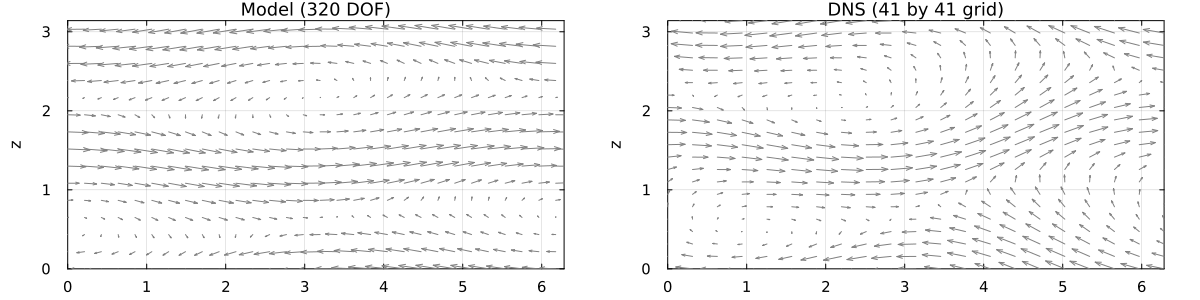

In [17]:
# Example usage:
# model = TWModel(α, γ, J, K, L, H)
# x_state = ξ_final[1:model.m]
# 
# Single plot
plot_xz_single(model, x_sol, title="TW Solution", add_baseflow=false, arrowsize=0.3)

# Comparison plot
plot_xz_comparison(model, x_sol, "data/tw1_plots/TW1-2pi1piRe200-40x49x40",
                   scale=0.7, save_path="xz_velocity_comparison.png", skip_x=2, skip_z=2, arrowsize=0.30)

In [18]:
"""
Improved visualization functions using Plots.jl with custom arrow rendering.
Based on John Gibson's cleaner visualization style.
"""

using Plots
using CloudAtlas
using DelimitedFiles

heatmap = Plots.heatmap
# ===== Arrow Drawing Utilities =====

"""
    invhypot(x, y)

Return 1/√(x² + y²) for (x,y) ≠ (0,0), or 0.0 for (x,y) == (0,0).
Useful for normalized quiver plots.
"""
invhypot(x, y) = (abs(x) + abs(y) > 0) ? 1/hypot(x, y) : 0.0

"""
    arrow0!(x, y, u, v; as=0.07, lc=:black, la=1, lw=1)

Draw a single arrow from (x,y) to (x+u, y+v) with arrowhead.

# Arguments
- `x, y`: Starting position
- `u, v`: Arrow components
- `as`: Arrow head size (0-1, fraction of arrow length)
- `lc`: Line color
- `la`: Line alpha (transparency)
- `lw`: Line width
"""
function arrow0!(x, y, u, v; as=0.07, lc=:black, la=1, lw=1.5)
    nuv = sqrt(u^2 + v^2)
    if nuv < 1e-10  # Skip tiny arrows
        return
    end
    v1, v2 = [u; v] / nuv, [-v; u] / nuv
    v4 = (3*v1 + v2) / 3.1623  # sqrt(10) to get unit vector
    v5 = v4 - 2*(v4'*v2)*v2
    v4, v5 = as*nuv*v4, as*nuv*v5
    plot!([x, x+u], [y, y+v], lc=lc, la=la, lw=lw, label="")
    plot!([x+u, x+u-v5[1]], [y+v, y+v-v5[2]], lc=lc, la=la, lw=lw, label="")
    plot!([x+u, x+u-v4[1]], [y+v, y+v-v4[2]], lc=lc, la=la, lw=lw, label="")
end

"""
    newquiver!(x, y, u, v; lc=:black, scale=1, arrowsize=0.1, lw=1.5)

Add quiver plot to current plot.

# Arguments
- `x`: Vector of x coordinates
- `y`: Vector of y coordinates  
- `u`: Matrix u[iy, ix] of x-components at (x[ix], y[iy])
- `v`: Matrix v[iy, ix] of y-components at (x[ix], y[iy])
- `lc`: Line color
- `scale`: Scale factor for arrow length
- `arrowsize`: Size of arrowhead (0-1)
- `lw`: Line width

Note: Matrix convention is u[iy, ix] to match standard plotting convention
where first index is row (y) and second is column (x).
"""
function newquiver!(x, y, u, v; lc=:black, scale=1, arrowsize=0.1, lw=1.5)
    u_scaled = u * scale
    v_scaled = v * scale
    nx = length(x)
    ny = length(y)
    
    # Verify dimensions
    if size(u) != (ny, nx) || size(v) != (ny, nx)
        error("Matrix dimensions don't match: u is $(size(u)), v is $(size(v)), but expected ($ny, $nx)")
    end
    
    for ix in 1:nx
        for iy in 1:ny
            arrow0!(x[ix], y[iy], u_scaled[iy, ix], v_scaled[iy, ix], 
                   lc=lc, as=arrowsize, lw=lw)
        end
    end
    plot!()
end

"""
    newquiver(x, y, u, v; lc=:black, scale=1, arrowsize=0.1)

Create new quiver plot.
"""
function newquiver(x, y, u, v; lc=:black, scale=1, arrowsize=0.1)
    plot()
    newquiver!(x, y, u, v; lc=lc, scale=scale, arrowsize=arrowsize)
end

# ===== Velocity Field Extraction =====

"""
    extract_xz_plane(model, x, y_val=0.0; Lx=2π, Lz=π, nx=40, nz=20, add_baseflow=false)

Extract (u, w) velocity components in xz-plane at fixed y.
Returns (x_grid, z_grid, u_matrix, w_matrix) ready for quiver plotting.

Note: Matrices are returned with shape (nz, nx) to match plotting convention.
"""
function extract_xz_plane(model::Union{CloudAtlas.ODEModel, CloudAtlas.TWModel}, 
                          x::Vector, y_val=0.0;
                          Lx=2π, Lz=π, nx=40, nz=20, 
                          add_baseflow=false)
    
    vf = VelocityField(model, x; add_baseflow=add_baseflow)
    
    x_grid = range(0, Lx, length=nx)
    z_grid = range(0, Lz, length=nz)
    
    # Build matrices: u[iz, ix] corresponds to (x[ix], z[iz])
    # First index is z (rows), second index is x (columns)
    u_matrix = [vf(:u, x_grid[ix], y_val, z_grid[iz]) for iz in 1:nz, ix in 1:nx]
    w_matrix = [vf(:w, x_grid[ix], y_val, z_grid[iz]) for iz in 1:nz, ix in 1:nx]
    
    return (x_grid, z_grid, u_matrix, w_matrix)
end

"""
    extract_xy_plane(model, x, z_val=0.0; Lx=2π, nx=40, ny=20, add_baseflow=false)

Extract (u, v) velocity components in xy-plane at fixed z.
Returns matrices with shape (ny, nx).
"""
function extract_xy_plane(model::Union{CloudAtlas.ODEModel, CloudAtlas.TWModel}, 
                          x::Vector, z_val=0.0;
                          Lx=2π, nx=40, ny=20,
                          add_baseflow=false)
    
    vf = VelocityField(model, x; add_baseflow=add_baseflow)
    
    x_grid = range(0, Lx, length=nx)
    y_grid = range(-1, 1, length=ny)
    
    # u[iy, ix] for (x[ix], y[iy])
    u_matrix = [vf(:u, x_grid[ix], y_grid[iy], z_val) for iy in 1:ny, ix in 1:nx]
    v_matrix = [vf(:v, x_grid[ix], y_grid[iy], z_val) for iy in 1:ny, ix in 1:nx]
    
    return (x_grid, y_grid, u_matrix, v_matrix)
end

"""
    extract_yz_plane(model, x, x_val=0.0; Lz=π, ny=20, nz=20, add_baseflow=false)

Extract (v, w) velocity components in yz-plane at fixed x.
Also returns u for heatmap background.
Returns matrices with shape (ny, nz).
"""
function extract_yz_plane(model::Union{CloudAtlas.ODEModel, CloudAtlas.TWModel}, 
                          x::Vector, x_val=0.0;
                          Lz=π, ny=20, nz=20,
                          add_baseflow=false)
    
    vf = VelocityField(model, x; add_baseflow=add_baseflow)
    
    y_grid = range(-1, 1, length=ny)
    z_grid = range(0, Lz, length=nz)
    
    # v[iy, iz] for (z[iz], y[iy])
    v_matrix = [vf(:v, x_val, y_grid[iy], z_grid[iz]) for iy in 1:ny, iz in 1:nz]
    w_matrix = [vf(:w, x_val, y_grid[iy], z_grid[iz]) for iy in 1:ny, iz in 1:nz]
    u_matrix = [vf(:u, x_val, y_grid[iy], z_grid[iz]) for iy in 1:ny, iz in 1:nz]
    
    return (z_grid, y_grid, v_matrix, w_matrix, u_matrix)
end

# ===== DNS Data Loading =====

"""
    myreaddlm(filename)

Read delimited file with comments (lines starting with %).
"""
myreaddlm(filename) = readdlm(filename, comments=true, comment_char='%')

"""
    load_dns_xz_plane(root::String)

Load DNS velocity field data for xz-plane.
Returns (u, w) matrices.
"""
function load_dns_xz_plane(root::String)
    u_xz = myreaddlm(root * "_u_xz.asc")
    w_xz = myreaddlm(root * "_w_xz.asc")
    return (u_xz, w_xz)
end

# ===== High-Level Plotting Functions =====

"""
    plot_xz_comparison(model, x, dns_root; 
                       scale=0.5, arrowsize=0.07, skip_x=2, skip_z=3,
                       add_baseflow=false, save_path=nothing)

Create side-by-side comparison of model vs DNS in xz-plane.
Uses John Gibson's clean arrow style.

# Arguments
- `model`: TWModel or ODEModel
- `x`: State vector (without cx, cz)
- `dns_root`: Root path for DNS files (e.g., "TW1-2pi1piRe200-40x49x40")
- `scale`: Arrow length scale
- `arrowsize`: Arrowhead size (0-1)
- `skip_x`, `skip_z`: Spacing between arrows (plot every nth arrow)
- `add_baseflow`: Add y baseflow to model
- `save_path`: Optional path to save figure
"""
function plot_xz_comparison(model::Union{CloudAtlas.ODEModel, CloudAtlas.TWModel}, 
                            x::Vector,
                            dns_root::String;
                            scale=0.5, arrowsize=0.07, 
                            skip_x=2, skip_z=3,
                            add_baseflow=false,
                            save_path::Union{String, Nothing}=nothing)
    
    Lx = 2π / model.α
    Lz = 2π / model.γ
    
    # Extract model velocity field
    x_grid, z_grid, u_model, w_model = extract_xz_plane(
        model, x, 0.0; Lx=Lx, Lz=Lz, nx=60, nz=30, add_baseflow=add_baseflow
    )
    
    # Load DNS data
    u_dns, w_dns = load_dns_xz_plane(dns_root)
    nz_dns, nx_dns = size(u_dns)
    x_dns = range(0, Lx, length=nx_dns)
    z_dns = range(0, Lz, length=nz_dns)
    
    # Calculate pixel dimensions for nice aspect ratio
    ypix = 300
    xpix = Int(round(Lx/Lz * ypix))
    
    # Create side-by-side plots
    p1 = plot()
    newquiver!(x_grid[1:skip_x:end], z_grid[1:skip_z:end], 
              u_model[1:skip_z:end, 1:skip_x:end], 
              w_model[1:skip_z:end, 1:skip_x:end],
              scale=scale, arrowsize=arrowsize, lc=:gray)
    plot!(xlim=(0, Lx), ylim=(0, Lz), 
          xlabel="x", ylabel="z",
                title="Model ($(length(model.Ψ)) DOF)",
          size=(xpix, ypix), 
          aspect_ratio=1,
          framestyle=:box,
          titlefontsize=12,
          tickfontsize=10)
    
    p2 = plot()
    newquiver!(x_dns[1:skip_x:end], z_dns[1:skip_z:end],
              u_dns[1:skip_z:end, 1:skip_x:end],
              w_dns[1:skip_z:end, 1:skip_x:end],
              scale=scale, arrowsize=arrowsize, lc=:gray)
    plot!(xlim=(0, Lx), ylim=(0, Lz),
          xlabel="x", ylabel="z", 
          title="DNS ($(nx_dns) by $(nz_dns) grid)",
          size=(xpix, ypix),
          aspect_ratio=1,
          framestyle=:box,
          titlefontsize=12,
          tickfontsize=10)
    
    # Combine plots
    p = plot(p1, p2, layout=(1, 2), size=(2*xpix, ypix))
    
    if save_path !== nothing
        savefig(p, save_path)
        println("Saved comparison to: $save_path")
    end
    
    return p
end

"""
    plot_xz_single(model, x; 
                   scale=0.5, arrowsize=0.07, skip_x=2, skip_z=3,
                   add_baseflow=false, title="", save_path=nothing)

Plot single xz-plane velocity field.
"""
function plot_xz_single(model::Union{CloudAtlas.ODEModel, CloudAtlas.TWModel}, 
                        x::Vector;
                        scale=0.5, arrowsize=0.07,
                        skip_x=2, skip_z=3,
                        add_baseflow=false,
                        title="",
                        save_path::Union{String, Nothing}=nothing)
    
    Lx = 2π / model.α
    Lz = 2π / model.γ
    
    x_grid, z_grid, u_matrix, w_matrix = extract_xz_plane(
        model, x, 0.0; Lx=Lx, Lz=Lz, nx=60, nz=30, add_baseflow=add_baseflow
    )
    
    ypix = 400
    xpix = Int(round(Lx/Lz * ypix))
    
    p = plot()
    newquiver!(x_grid[1:skip_x:end], z_grid[1:skip_z:end],
              u_matrix[1:skip_z:end, 1:skip_x:end],
              w_matrix[1:skip_z:end, 1:skip_x:end],
              scale=scale, arrowsize=arrowsize, lc=:gray)
    
    plot!(xlim=(0, Lx), ylim=(0, Lz),
          xlabel="x", ylabel="z",
          title=title,
          size=(xpix, ypix),
          aspect_ratio=1,
          framestyle=:box)
    
    if save_path !== nothing
        savefig(p, save_path)
        println("Saved figure to: $save_path")
    end
    
    return p
end

# Example usage:
# model = TWModel(α, γ, J, K, L, H)
# x_state = ξ_final[1:model.m]
# 
# # Single plot
# plot_xz_single(model, x_state, title="TW Solution", add_baseflow=false)
#
# # Comparison plot
# plot_xz_comparison(model, x_state, "TW1-2pi1piRe200-40x49x40",
#                    scale=0.5, save_path="velocity_comparison.png")
#
# # YZ plane with heatmap
# plot_yz_single(model, x_state, title="YZ Cross-section", 
#                add_baseflow=false, colormap=:RdBu)

"""
    plot_yz_single(model, x; 
                   scale=0.5, arrowsize=0.07, skip_y=2, skip_z=3,
                   add_baseflow=false, title="", colormap=:RdBu,
                   save_path=nothing)

Plot single yz-plane with u heatmap and (v,w) arrows.
"""
function plot_yz_single(model::Union{CloudAtlas.ODEModel, CloudAtlas.TWModel}, 
                        x::Vector;
                        scale=0.5, arrowsize=0.07,
                        skip_y=2, skip_z=3,
                        add_baseflow=false,
                        title="",
                        colormap=:RdBu,
                        save_path::Union{String, Nothing}=nothing)
    
    Lz = 2π / model.γ
    
    z_grid, y_grid, v_matrix, w_matrix, u_matrix = extract_yz_plane(
        model, x, 0.0; Lz=Lz, ny=40, nz=30, add_baseflow=add_baseflow
    )
    
    # Calculate pixel dimensions
    ypix = 400
    zpix = Int(round(Lz/2 * ypix))
    
    p = heatmap(z_grid, y_grid, u_matrix, 
                c=colormap, 
                clim=(-1, 1),
                aspect_ratio=1,
                framestyle=:box)
    
    newquiver!(z_grid[1:skip_z:end], y_grid[1:skip_y:end],
              w_matrix[1:skip_y:end, 1:skip_z:end],
              v_matrix[1:skip_y:end, 1:skip_z:end],
              scale=scale, arrowsize=arrowsize, lc=:black, lw=1.5)
    
    plot!(xlim=(0, Lz), ylim=(-1, 1),
          xlabel="z", ylabel="y",
          title=title,
          size=(zpix, ypix),
          colorbar_title="u")
    
    if save_path !== nothing
        savefig(p, save_path)
        println("Saved figure to: $save_path")
    end
    
    return p
end

"""
    plot_yz_comparison(model, x, dns_root;
                       scale=0.5, arrowsize=0.07, skip_y=2, skip_z=3,
                       add_baseflow=false, colormap=:RdBu,
                       save_path=nothing)

Create side-by-side comparison of model vs DNS in yz-plane with u heatmap.
"""
function plot_yz_comparison(model::Union{CloudAtlas.ODEModel, CloudAtlas.TWModel}, 
                            x::Vector,
                            dns_root::String;
                            scale=0.5, arrowsize=0.07,
                            skip_y=2, skip_z=3,
                            add_baseflow=false,
                            colormap=:RdBu,
                            save_path::Union{String, Nothing}=nothing)
    
    Lz = 2π / model.γ
    
    # Extract model data
    z_grid, y_grid, v_model, w_model, u_model = extract_yz_plane(
        model, x, 0.0; Lz=Lz, ny=40, nz=30, add_baseflow=add_baseflow
    )
    
    # Load DNS data
    u_dns = myreaddlm(dns_root * "_u_yz.asc")
    v_dns = myreaddlm(dns_root * "_v_yz.asc")
    w_dns = myreaddlm(dns_root * "_w_yz.asc")
    
    ny_dns, nz_dns = size(v_dns)
    z_dns = range(0, Lz, length=nz_dns)
    y_dns = range(-1, 1, length=ny_dns)
    
    # Calculate dimensions
    ypix = 400
    zpix = Int(round(Lz/2 * ypix))
    
    # Model plot
    p1 = heatmap(z_grid, y_grid, u_model,
                c=colormap,
                clim=(-1, 1),
                aspect_ratio=1,
                framestyle=:box,
                title="Model ($(length(model.Ψ)) DOF)",
                titlefontsize=12)
    
    newquiver!(z_grid[1:skip_z:end], y_grid[1:skip_y:end],
              w_model[1:skip_y:end, 1:skip_z:end],
              v_model[1:skip_y:end, 1:skip_z:end],
              scale=scale, arrowsize=arrowsize, lc=:black, lw=1.5)
    
    plot!(xlim=(0, Lz), ylim=(-1, 1),
          xlabel="z", ylabel="y",
          size=(zpix, ypix))
    
    # DNS plot - need to reverse y-direction
    p2 = heatmap(z_dns, y_dns, reverse(u_dns, dims=1),
                c=colormap,
                clim=(-1, 1),
                aspect_ratio=1,
                framestyle=:box,
                title="DNS ($(ny_dns) by $(nz_dns) grid)",
                titlefontsize=12)
    
    # Reverse v and w arrays in y-direction for DNS
    v_dns_rev = reverse(v_dns, dims=1)
    w_dns_rev = reverse(w_dns, dims=1)
    
    
    newquiver!(z_dns[1:skip_z:end], y_dns[1:skip_y:end],
              w_dns[1:skip_y:end, 1:skip_z:end],
              v_dns[1:skip_y:end, 1:skip_z:end],
              scale=scale, arrowsize=arrowsize, lc=:black, lw=1.5)
    
    plot!(xlim=(0, Lz), ylim=(-1, 1),
          xlabel="z", ylabel="y",
          size=(zpix, ypix))
    
    # Combine
    p = plot(p1, p2, layout=(1, 2), size=(2*zpix, ypix))
    
    if save_path !== nothing
        savefig(p, save_path)
        println("Saved comparison to: $save_path")
    end
    
    return p
end

plot_yz_comparison

Saved comparison to: xz_velocity_comparison.png


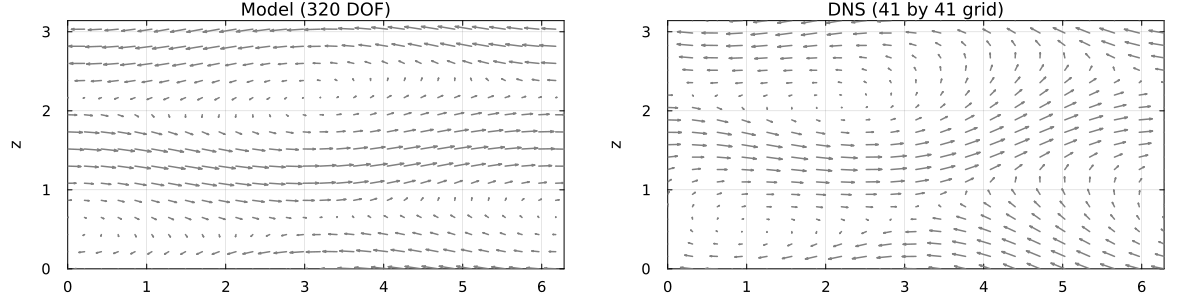

In [19]:
# Example usage:
# model = TWModel(α, γ, J, K, L, H)
# x_state = ξ_final[1:model.m]
# 
# Single plot
plot_xz_single(model, x_sol, title="TW Solution", add_baseflow=false, arrowsize=0.3)

# Comparison plot
plot_xz_comparison(model, x_sol, "data/tw1_plots/TW1-2pi1piRe200-40x49x40",
                   scale=0.5, save_path="xz_velocity_comparison.png", skip_x=2, skip_z=2, arrowsize=0.20)

Saved comparison to: yz_velocity_comparison.png


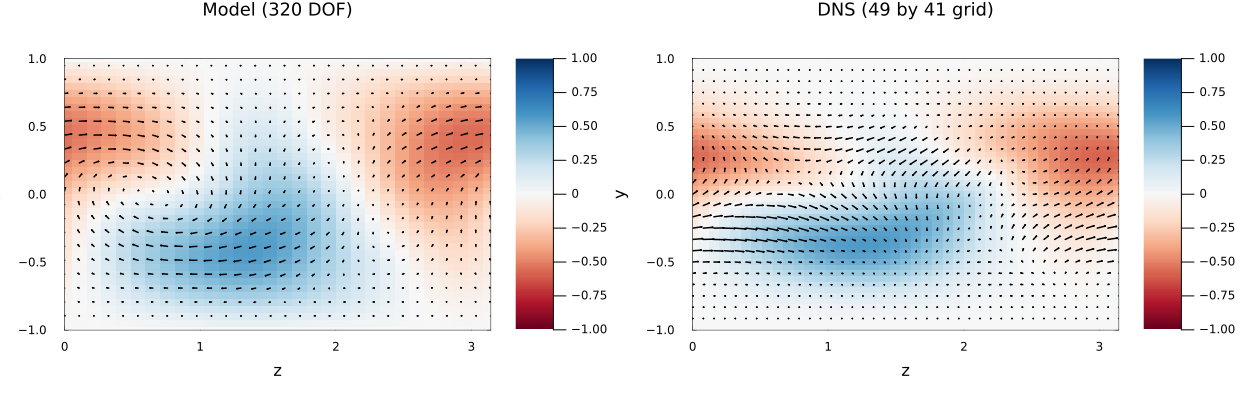

In [20]:
# Example usage:
# model = TWModel(α, γ, J, K, L, H)
# x_state = ξ_final[1:model.m]
# 
# Single plot
# plot_yz_single(model, x_sol, title="TW Solution", add_baseflow=false, arrowsize=0.3)

# Comparison plot
plot_yz_comparison(model, x_sol, "data/tw1_plots/TW1-2pi1piRe200-40x49x40",
                   scale=0.5, save_path="yz_velocity_comparison.png", skip_z=1, skip_y=2)